In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/Documents/optimal-control-notes-code/code/with-notes/exercise-2`
Precompiling project...
  ✓ ECOS_jll
  ✓ SpecialFunctions
  ✓ DiffRules
  ✓ ColorVectorSpace → SpecialFunctionsExt
  ✓ ForwardDiff
  ✓ ColorSchemes
  ✓ CommonMark
  ✓ PyCall
  ✓ JuliaFormatter
  ✓ PyPlot
  ✓ JupyterFormatter
  ✓ PlotUtils
  ✓ PlotThemes
  ✓ RecipesPipeline
  ✓ Plots
  ✓ Plots → IJuliaExt
  ✓ Plots → UnitfulExt
  ✓ MathOptInterface
  ✓ ECOS
  ✓ Convex
  20 dependencies successfully precompiled in 75 seconds. 152 already precompiled.
  1 dependency had warnings during precompilation:
┌ JuliaFormatter [98e50ef6-434e-11e9-1051-2b60c6c9e899]
│  WARNING: method definition for p_globalrefcmd at /home/xwc/.julia/packages/JuliaFormatter/JHBE6/src/styles/default/pretty.jl:529 declares type variable S but does not use it.
└  


In [2]:
using LaTeXStrings;
using Plots;
pyplot();
PyPlot.matplotlib.rc("text", usetex = true);
PyPlot.matplotlib.rc("font", family = "Times New Roman");
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}");

using JupyterFormatter;
enable_autoformat();

In [3]:
using LinearAlgebra, Plots;
import ForwardDiff as FD;
using Test;
import Convex as cvx;
import ECOS;
using Random;

## Julia Warnings:

1. For a function `foo(x::Vector)` with 1 input argument, it is not neccessary to do `df_dx = FD.jacobian(_x -> foo(_x), x)`. Instead you can just do `df_dx = FD.jacobian(foo, x)`. If you do the first one, it can dramatically slow down your compliation time. 

2. Do not define functions inside of other functions like this:
```julia
function foo(x)
    # main function foo 
    
    function body(x)
        # function inside function (DON'T DO THIS)
        return 2*x 
    end
    
    return body(x)
end
```
This will also slow down your compilation time dramatically.

# Q1: Finite-Horizon LQR
For this problem we are going to consider a "double integrator" for our dynamics model. This system has a state $x \in \mathbb{R}^4$, and control $u \in \mathbb{R}^2$, where the state describes the 2D position $p$ and velocity $v$ of an object, and the control is the acceleration $a$ of this object.  The state and control are the following:
$$\begin{align} x &= [p_1, p_2, v_1, v_2] \\ u &= [a_1, a_2] \end{align}$$
And the continuous time dynamics for this system are the following:
$$\begin{align} \dot{x} =  \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix} x + \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \end{align} u$$

In [5]:
# double integrator dynamics 
function double_integrator_AB(dt)::Tuple{Matrix,Matrix}
    Ac = [
        0 0 1 0
        0 0 0 1
        0 0 0 0
        0 0 0 0.0
    ]
    Bc = [
        0 0
        0 0
        1 0
        0 1
    ]
    nx, nu = size(Bc)

    # matrix exponential 
    H = exp([Ac Bc; zeros(nu, nx + nu)] * dt)
    A = H[1:nx, 1:nx]
    B = H[1:nx, (nx+1):(nx+nu)]

    return A, B
end;

In [7]:
@testset "discrete time dynamics" begin
    dt = 0.1
    A, B = double_integrator_AB(dt)

    x = [1, 2, 3, 4.0]
    u = [-1, -3.0]

    @test isapprox((A * x + B * u), [1.295, 2.385, 2.9, 3.7]; atol = 1e-10)

end;

Test Summary:          | Pass  Total  Time
discrete time dynamics |    1      1  0.0s


## Part (A): Finite Horizon LQR via Convex Optimization

We are now going to solve the finite horizon LQR problem with convex optimization. As we went over in class, this problem requires $Q \in S_+$(Q is symmetric positive semi-definite) and $R \in S_{++}$ (R is symmetric positive definite).  With this, the optimization problem can be stated as the following:
$$ \begin{align} \min_{x_{1:N},u_{1:N-1}} \quad & \sum_{i=1}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st} \quad & x_1 = x_{\text{IC}} \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = 1,2,\ldots,N-1 
 \end{align}$$
This problem is a convex optimization problem since the cost function is a convex quadratic and the constraints are all linear equality constraints. We will setup and solve this exact problem using the `Convex.jl` modeling package. We will fill out a function `Xcvx,Ucvx = convex_trajopt(A,B,Q,R,Qf,N,x_ic)`, where we will form and solve the above optimization problem. 

In [15]:
# utilities for converting to and from vector of vectors <-> matrix
function mat_from_vec(X::Vector{Vector{Float64}})::Matrix
    # convert a vector of vector to a matrix
    # return hcat(X...)
    return reduce(hcat, X)  # more efficient
end;

In [19]:
function vec_from_mat(Xm::Matrix)::Vector{Vector{Float64}}
    # convert a matrix to a vector of vector
    return [x for x in eachcol(Xm)]
end;

In [27]:
function convex_trajopt(
    A::Matrix,
    B::Matrix,
    Q::Matrix,
    R::Matrix,
    Qf::Matrix,
    N::Int64,
    x_ic::Vector;
    verbose = false,
)::Tuple{Vector{Vector{Float64}},Vector{Vector{Float64}}}
    # check size of everything
    nx, nu = size(B)
    @assert size(A) == (nx, nx)
    @assert size(Q) == (nx, nx)
    @assert size(R) == (nu, nu)
    @assert size(Qf) == (nx, nx)
    @assert length(x_ic) == nx

    # create cvx variable
    X = cvx.Variable(nx, N)
    U = cvx.Variable(nu, N - 1)

    # create cost
    cost = 0
    for k = 1:(N-1)
        cost += 0.5 * cvx.quadform(X[:, k], Q) + 0.5 * cvx.quadform(U[:, k], R)
    end
    cost += 0.5 * cvx.quadform(X[:, N], Qf)

    # initialize cvx problem
    prob = cvx.minimize(cost)

    # initial condition constraint
    prob.constraints += (X[:, 1] == x_ic)

    for k = 1:(N-1)
        # dynamic constraints
        prob.constraints += (X[:, k+1] == A * X[:, k] + B * U[:, k])
    end

    # solve problem (silent solver tells us the output)
    cvx.solve!(prob, ECOS.Optimizer; silent_solver = !verbose)

    # if prob.status != cvx::Optimal
    #     error("Convex.jl problem failed to solve for some reason")
    # end
    display(prob.status)

    # convert the solution matrices into vectors of vectors
    X = vec_from_mat(X.value)
    U = vec_from_mat(U.value)

    return X, U
end;

Now let's solve this problem for a given initial condition, and simulate it to see how it does:

OPTIMAL::TerminationStatusCode = 1

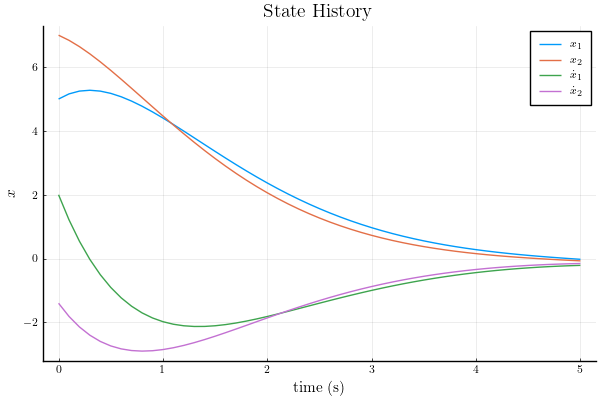

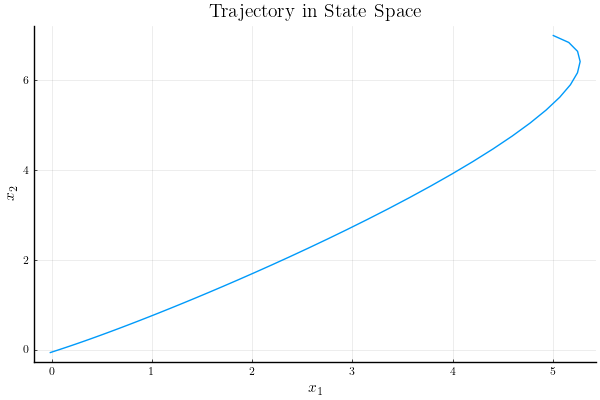

Test Summary:     | Pass  Total  Time
LQR via Convex.jl |    4      4  0.7s


In [35]:
@testset "LQR via Convex.jl" begin

    # problem setup stuff 
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    Q = diagm(ones(nx))  # do not use I()
    R = diagm(ones(nu))
    Qf = 5 * Q

    # initial condition 
    x_ic = [5, 7, 2, -1.4]

    # setup and solve our convex optimization problem (verbose = true for submission)
    Xcvx, Ucvx = convex_trajopt(A, B, Q, R, Qf, N, x_ic; verbose = false)

    # now let's simulate using Ucvx on our discrete time dynamics
    Xsim = [zeros(nx) for i = 1:N]
    Xsim[1] = 1 * x_ic
    for i = 1:N-1
        Xsim[i+1] = A * Xsim[i] + B * Ucvx[i]
    end

    #----------------------plotting-----------------------
    Xsim_m = mat_from_vec(Xsim)

    # plot state history 
    display(
        plot(
            t_vec,
            Xsim_m',
            label = [L"x_1" L"x_2" L"\dot x_1" L"\dot x_2"],
            title = "State History",
            xlabel = "time (s)",
            ylabel = L"x",
        ),
    )

    # plot trajectory in x1 x2 space 
    display(
        plot(
            Xsim_m[1, :],
            Xsim_m[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            label = "",
        ),
    )

    PyPlot.close()  # prevent redundant plots
    #----------------------plotting-----------------------

    # tests 
    @test 1e-14 < maximum(norm.(Xsim .- Xcvx, Inf)) < 1e-3
    @test isapprox(Ucvx[1], [-7.8532442316767, -4.127120137234], atol = 1e-3)
    @test isapprox(Xcvx[end], [-0.02285990, -0.07140241, -0.21259, -0.1540299], atol = 1e-3)
    @test 1e-14 < norm(Xcvx[end] - Xsim[end]) < 1e-3
end;

### Bellman's Principle of Optimality
Now we will test Bellman's Principle of optimality. This can be phrased in many different ways, but the main gist is that any section of an optimal trajectory must be optimal. Our original optimization problem was the above problem:
$$ \begin{align} \min_{x_{1:N},u_{1:N-1}} \quad & \sum_{i=1}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st} \quad & x_1 = x_{\text{IC}} \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = 1,2,\ldots,N-1 
 \end{align}$$
which has a solution $x^*_{1:N},u^*_{1:N-1}$. Now let's look at optimizing over a subsection of this trajectory. That means that instead of solving for $x_{1:N},u_{1:N-1}$, we are now solving for $x_{L:N},u_{L:N-1}$ for some new timestep $1 < L < N$. What we are going to do is take the initial condition from $x^*_L$ from our original optimization problem, and setup a new optimization problem that optimizes over $x_{L:N},u_{L:N-1}$:
$$ \begin{align} \min_{x_{L:N},u_{L:N-1}} \quad & \sum_{i=L}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st     } \quad & x_L = x^*_L \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = L,L + 1,\ldots,N-1 
 \end{align}$$

OPTIMAL::TerminationStatusCode = 1

OPTIMAL::TerminationStatusCode = 1

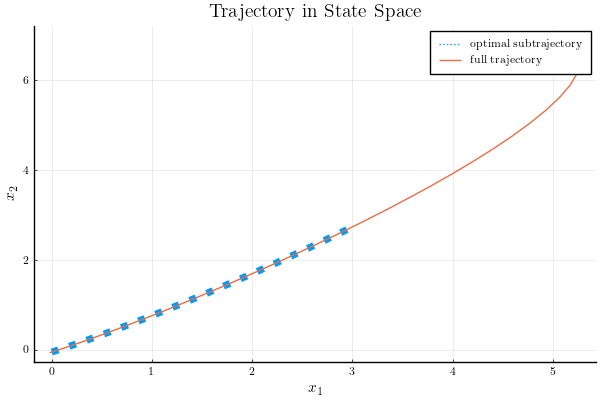

Test Summary:                     | Pass  Total  Time
Bellman's Principle of Optimality |    4      4  1.1s


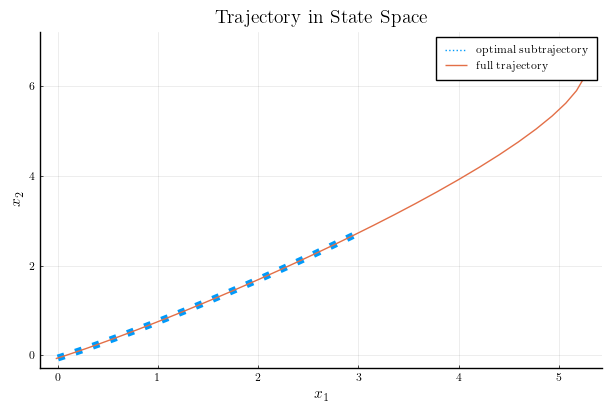

Test.DefaultTestSet("Bellman's Principle of Optimality", Any[], 4, false, false, true, 1.692931563579863e9, 1.692931564680345e9, false)

In [36]:
@testset "Bellman's Principle of Optimality" begin

    # problem setup 
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    x0 = [5, 7, 2, -1.4] # initial condition 
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 5 * Q

    # solve for X_{1:N}, U_{1:N-1} with convex optimization
    Xcvx1, Ucvx1 = convex_trajopt(A, B, Q, R, Qf, N, x0; verbose = false)

    # now let's solve a subsection of this trajectory 
    L = 18
    N_2 = N - L + 1

    # here is our updated initial condition from the first problem 
    x0_2 = Xcvx1[L]
    Xcvx2, Ucvx2 = convex_trajopt(A, B, Q, R, Qf, N_2, x0_2; verbose = false)

    # test if these trajectories match for the times they share 
    U_error = Ucvx1[L:end] .- Ucvx2
    X_error = Xcvx1[L:end] .- Xcvx2
    @test 1e-14 < maximum(norm.(U_error)) < 1e-3
    @test 1e-14 < maximum(norm.(X_error)) < 1e-3


    # ---------------------------plotting ------------------------------
    X1m = mat_from_vec(Xcvx1)
    X2m = mat_from_vec(Xcvx2)
    plot(X2m[1, :], X2m[2, :], label = "optimal subtrajectory", lw = 5, ls = :dot)
    display(
        plot!(
            X1m[1, :],
            X1m[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            label = "full trajectory",
        ),
    )
    PyPlot.close()
    # ---------------------------plotting ------------------------------

    @test isapprox(
        Xcvx1[end],
        [-0.02285990, -0.07140241, -0.21259, -0.1540299],
        rtol = 1e-3,
    )
    @test 1e-14 < norm(Xcvx1[end] - Xcvx2[end], Inf) < 1e-3
end